# Decision Tree

A **Decision Tree** is a **Supervised Machine Learning Algorithm**.

It can be used for:

- Classification ✅
- Regression ✅

A Decision Tree makes decisions by asking a series of **Yes/No questions** until it reaches a final prediction.

Think of it like a flowchart.

---

# Intuition

Suppose you want to decide whether to play cricket.

```
                Weather?
               /        \
            Sunny      Rainy
             /            \
      Humidity?          Don't Play
        /    \
      High   Low
       |      |
  Don't Play  Play
```

The model keeps asking questions until it reaches a decision.

---

# Example

Suppose we have a Heart Disease dataset.

| Age | Cholesterol | Heart Disease |
|-----|--------------|---------------|
| 25 | Low | No |
| 32 | Low | No |
| 45 | High | Yes |
| 52 | High | Yes |
| 60 | High | Yes |

A possible Decision Tree:

```
          Cholesterol?

          High      Low
           |         |
          Yes       No
```

Instead of using one formula like Logistic Regression,

Decision Trees learn **rules**.

---

# How Does a Decision Tree Work?

```
Dataset
   │
   ▼
Find Best Feature
   │
   ▼
Split Dataset
   │
   ▼
Repeat Again
   │
   ▼
Leaf Node
```

The tree keeps splitting until it decides the class.

---

# Terminology

```
                 Root Node
                     │
          ┌──────────┴──────────┐
          │                     │
      Internal Node        Internal Node
          │                     │
      Leaf Node           Leaf Node
```

---

## Root Node

The first question.

Example

```
Is Cholesterol High?
```

---

## Internal Node

Any node that asks another question.

```
Age > 45?
```

---

## Leaf Node

Final prediction.

```
Heart Disease

or

No Heart Disease
```

---

# Decision Tree Classifier

Used when the target variable is **categorical**.

Examples

- Yes / No
- Spam / Not Spam
- Disease / Healthy

Scikit-Learn

```python
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

# How Does the Tree Decide the Best Split?

The model asks:

> **Which feature gives me the purest groups after splitting?**

To measure this, it uses:

- Gini Impurity
- Entropy
- Information Gain

---

# What is Impurity?

Impurity tells us **how mixed a node is**.

---

## Pure Node

```
Yes

Yes

Yes

Yes
```

Only one class.

Impurity = **0**

---

## Impure Node

```
Yes

No

Yes

No
```

Mixed classes.

High impurity.

---

# Gini Impurity

Gini measures how mixed a node is.

Formula

$$
Gini
=
1
-
\sum_{i=1}^{n}
p_i^2
$$

where

```
p = probability of each class
```

---

# Example

Suppose a node contains

```
8 Yes

2 No
```

Probability

```
P(Yes)=0.8

P(No)=0.2
```

Gini

$$
1-(0.8^2+0.2^2)
$$

$$
=
1-(0.64+0.04)
$$

$$
=
0.32
$$

Low impurity.

---

Another node

```
5 Yes

5 No
```

Gini

$$
1-(0.5^2+0.5^2)
$$

$$
=
1-(0.25+0.25)
$$

$$
=
0.5
$$

Higher impurity.

---

# Entropy

Entropy also measures impurity.

Formula

$$
Entropy
=
-
\sum
p_i
\log_2(p_i)
$$

---

Example

Node

```
8 Yes

2 No
```

Entropy

≈

```
0.72
```

Node

```
5 Yes

5 No
```

Entropy

```
1.0
```

Higher entropy

↓

More mixed.

---

# Gini vs Entropy

```
Pure Node

↓

Gini = 0

Entropy = 0
```

```
Completely Mixed

↓

High Gini

High Entropy
```

Both try to find the purest split.

---

# Information Gain

Information Gain tells us

> **How much impurity decreases after a split.**

Formula

$$
Information\ Gain
=
Parent\ Entropy
-
Weighted\ Child\ Entropy
$$

Higher Information Gain

↓

Better split.

---

# Simple Example

Suppose we have:

```
10 Patients

6 Heart Disease

4 Healthy
```

Parent Node

```
Mixed
```

Now split using

```
Cholesterol
```

Left

```
5 Disease

1 Healthy
```

Right

```
1 Disease

3 Healthy
```

Both child nodes are much purer than the parent.

Therefore

```
Information Gain

High
```

This is a good split.

---

# Complete Process

```
Dataset
   │
   ▼
Calculate Gini / Entropy
   │
   ▼
Find Best Split
   │
   ▼
Split Dataset
   │
   ▼
Repeat Until Leaf Node
```

---

# Hyperparameters

## criterion

How impurity is measured.

```python
criterion="gini"
```

or

```python
criterion="entropy"
```

or

```python
criterion="log_loss"
```

---

## max_depth

Maximum depth of the tree.

```python
max_depth=5
```

Small depth

↓

Underfitting

Large depth

↓

Overfitting

---

## min_samples_split

Minimum samples required before splitting.

```python
min_samples_split=5
```

---

## min_samples_leaf

Minimum samples allowed in each leaf.

```python
min_samples_leaf=2
```

Helps reduce overfitting.

---

## max_features

Maximum number of features considered for each split.

```python
max_features="sqrt"
```

Common values

```
None

sqrt

log2
```

---

## random_state

Makes results reproducible.

```python
random_state=42
```

---

# Scikit-Learn Syntax

```python
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

# Advantages

✅ Easy to understand

✅ Easy to visualize

✅ Handles numerical and categorical data

✅ No feature scaling required

✅ Captures non-linear relationships

---

# Disadvantages

❌ Easily overfits

❌ Small data changes can produce a different tree

❌ Lower accuracy than ensemble methods (Random Forest, XGBoost)

---

# When Should We Use Decision Trees?

Use when

- Interpretability is important
- Rules are easy to explain
- Non-linear relationships exist
- Feature scaling is not desired

Examples

- Heart Disease Prediction
- Loan Approval
- Customer Churn
- Fraud Detection

---

# Comparison

| Algorithm | Best For |
|-----------|----------|
| Logistic Regression | Linear decision boundary |
| Naive Bayes | Probability-based classification |
| KNN | Similarity-based classification |
| SVM | Maximum margin classification |
| Decision Tree | Rule-based decisions |

---

# Rule of Thumb

```
Need an explainable model?

↓

Decision Tree
```

```
Need a simple linear classifier?

↓

Logistic Regression
```

```
Need a similarity-based model?

↓

KNN
```

```
Need maximum margin?

↓

SVM
```

---

# One-Line Definition

> **A Decision Tree is a supervised learning algorithm that predicts a class by recursively splitting the data into increasingly pure groups using measures such as Gini Impurity or Entropy.**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
# Load Iris Data set 
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
iris
# I get two things data and target 
# data contains input featurs and target contains target featur

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
print(iris["DESCR"])  # it will description of Dataset

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
iris["target"] 
# 3 category 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
iris.feature_names


['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

___
# X and Y split 
___

In [15]:
X = pd.DataFrame(iris["data"], columns=iris.feature_names)
y = iris["target"]

In [14]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

___
# Train Test Split
___

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state=42)

___
# Model Traing

``` 
For decision we dont need to Standardize columns
```
___

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Visualize the Tree

```python 

from skleran  import tree

tree.plot_tree( model_name, filled= true)
```
``` 
We use this function plot tree

In [ ]:
from sklearn import tree
# usually this Knda Decision Tree leads 

[Text(0.3076923076923077, 0.9285714285714286, 'x[2] <= 2.45\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0.0, 39.0, 38.0]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 34\nvalue = [0, 34, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.21\nsamples = 42\nvalue = [0, 5, 37]'),
 Text(0.38461538461538464, 0.5, 'x[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [

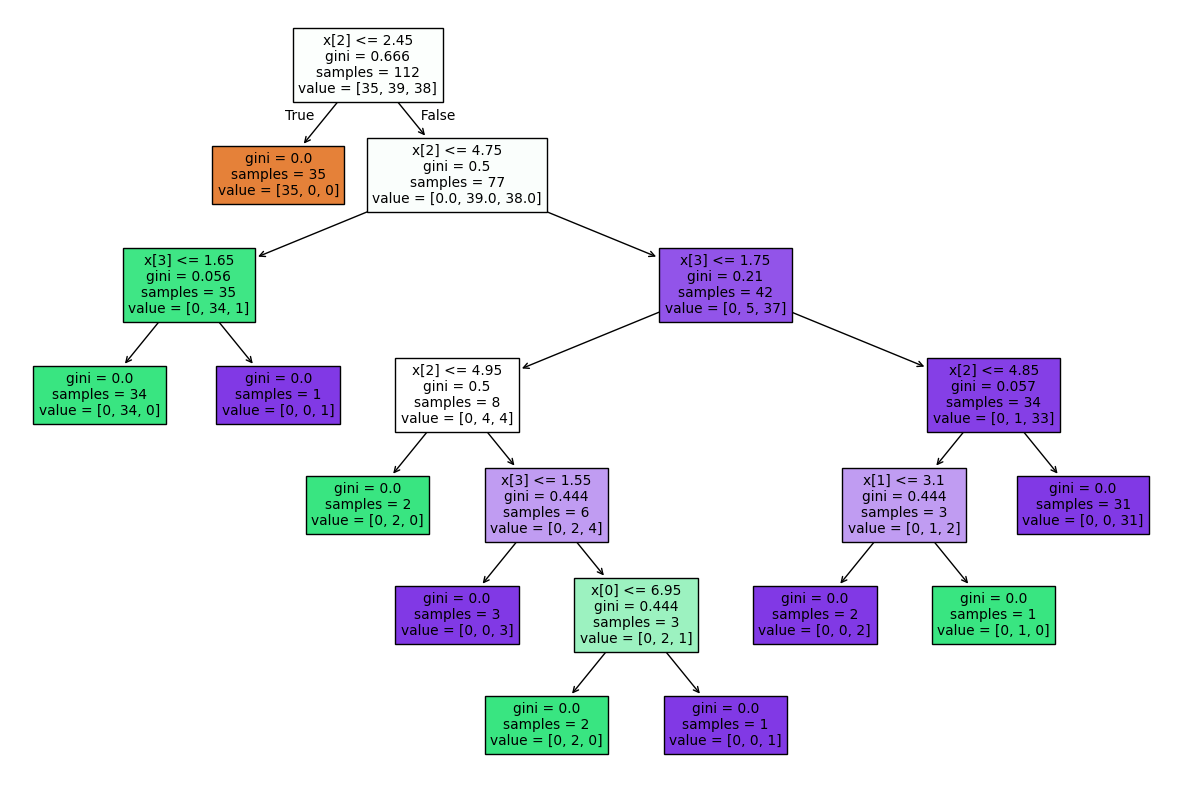

In [22]:
plt.figure(figsize=(15, 10))
tree.plot_tree(model, filled= True)

```
Usally this kinda decission Tree leads to OVERFITTING 

we will use POST PRUNING AND PRE Pruning 

value = [2 , 45, 2] means [ 1st catgeory instances , 2nd category instances , 3rd category instances ]

so 1st category insatnces = 2,
   2nd  .............     = 45,
   3rd ..............     = 2

so we get max of 2nd category 


observe in above graph at depth level 2 
we values = [0 , 34 , 1] on left side  ---> max category = 2nd 
   values = [ 0, 5,  37] on right side  --->> max category = 3rd

as in the level the other 2 categories are very small we'll ignore them and extend tree only till level 2 




# Post Pruning using `max_depth`

`max_depth` is a **pre-pruning** technique (even though many beginners call it post pruning).

It limits **how deep a Decision Tree is allowed to grow**.

---

# Why Do We Need `max_depth`?

Suppose we let the tree grow without any limit.

```
                Root
               /    \
              A      B
             / \    / \
            C   D  E   F
           / \
          G   H
         / \
        I   J
```

The tree keeps splitting until it memorizes the training data.

Result:

```
Training Accuracy

99%
```

```
Testing Accuracy

80%
```

This is **Overfitting**.

---

# Idea of `max_depth`

Instead of allowing the tree to grow forever,

we tell it:

```
Maximum Depth = 3
```

After reaching depth 3,

```
STOP
```

No more splits are allowed.

---

# Example

Without `max_depth`

```
Depth = 6

            Root
           /    \
         A        B
        / \
       C   D
      / \
     E   F
    / \
   G   H
```

Very deep tree.

---

With

```python
max_depth = 2
```

Tree becomes

```
            Root
           /    \
         A        B
        / \
       C   D
```

The lower branches are never created.

---

# What is Tree Depth?

```
Level 0

        Root
```

```
Level 1

      /     \
```

```
Level 2

    /  \    /  \
```

Depth counts the number of levels from the root.

Example

```
Root

↓

Child

↓

Grandchild
```

Depth = **2**

---

# Choosing `max_depth`

```
Small max_depth

↓

Simple Tree

↓

May Underfit
```

```
Large max_depth

↓

Complex Tree

↓

May Overfit
```

---

# Visualization

```
max_depth = 1

      🌳
```

```
max_depth = 3

      🌳🌳🌳
```

```
max_depth = None

🌳🌳🌳🌳🌳🌳🌳🌳🌳
```

---

# Scikit-Learn Syntax

```python
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
```

---

# Hyperparameter Tuning

```python
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
```

---

# Effect of Different Values

| `max_depth` | Tree Size | Result |
|-------------|-----------|--------|
| 1 | Very Small | Underfitting |
| 3 | Medium | Good Balance |
| 5 | Larger | Better Learning |
| None | Very Large | Risk of Overfitting |

---

# Rule of Thumb

```
Tree Overfitting?

↓

Reduce max_depth
```

```
Tree Underfitting?

↓

Increase max_depth
```

---

# Note

Technically, **`max_depth` is a pre-pruning parameter**, because it **prevents the tree from growing too deep**. True **post-pruning** is done **after** the full tree is built, typically using `ccp_alpha` (Cost Complexity Pruning).

---

# One-Line Definition

> **`max_depth` limits how deep a Decision Tree can grow, helping reduce overfitting by preventing the model from creating unnecessary branches.**

In [24]:
model_post_prune = DecisionTreeClassifier(max_depth=2)

model_post_prune.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0.0, 39.0, 38.0]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.21\nsamples = 42\nvalue = [0, 5, 37]')]

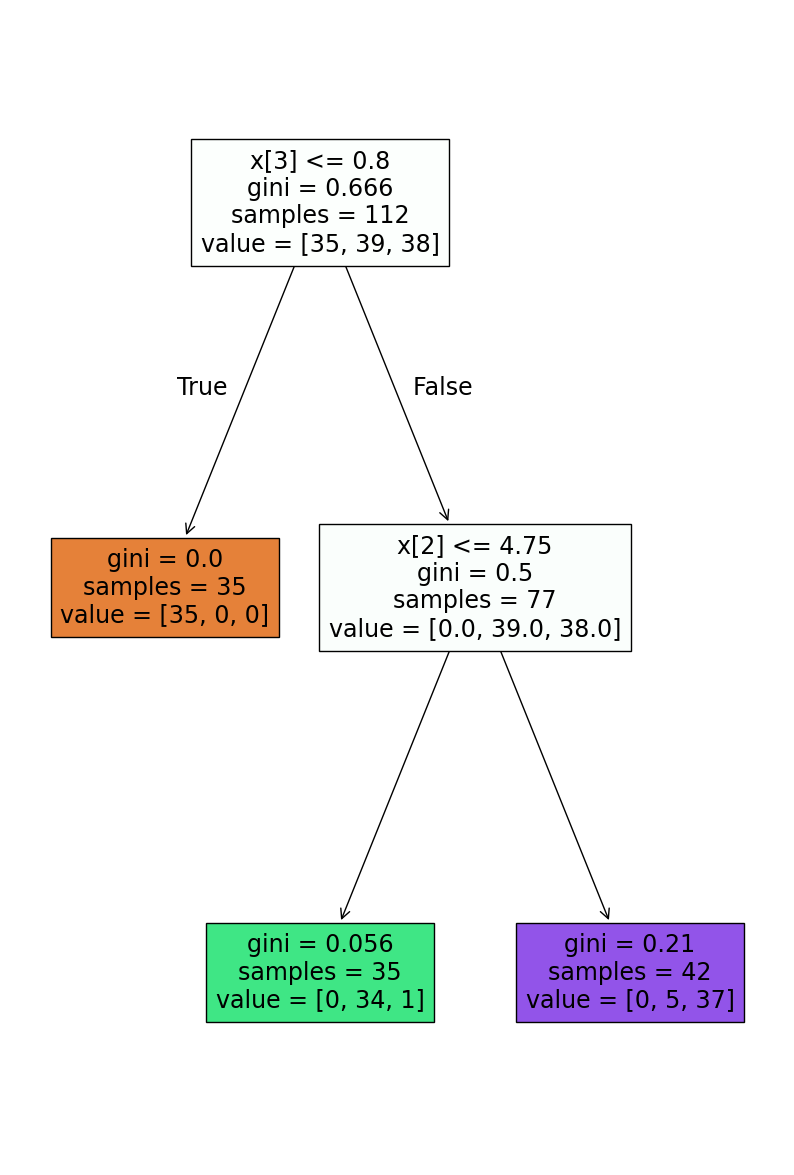

In [25]:
from sklearn import tree

plt.figure(figsize=(10, 15))
tree.plot_tree(model_post_prune, filled= True)

___
# Metrics
__

In [26]:
from sklearn.metrics import classification_report , accuracy_score

In [27]:
print(classification_report(y_test, model_post_prune.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.91      0.95        11
           2       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



_____
____
____

# PRE - PRUNING

# Pre-Pruning (Early Stopping)

Pre-Pruning is a technique used to **prevent overfitting** in a Decision Tree.

The idea is simple:

> **Stop the tree from growing too large while it is being built.**

Instead of growing a huge tree and cutting branches later, we **stop unnecessary splits early**.

---

# Why Do We Need Pre-Pruning?

Suppose we allow the tree to grow without any limits.

```
                Root
               /    \
              A      B
             / \    / \
            C   D  E   F
           / \
          G   H
         / \
        I   J
```

The tree memorizes the training data.

Result

```
Training Accuracy

99%
```

```
Testing Accuracy

80%
```

This is called **Overfitting**.

---

# Idea of Pre-Pruning

Instead of letting the tree grow forever,

```
Start Building Tree
        │
        ▼
Check Stopping Rules
        │
        ▼
If Rule Satisfied
        │
        ▼
STOP Splitting
```

---

# Common Pre-Pruning Parameters

```
Decision Tree
      │
      ├── max_depth
      ├── min_samples_split
      ├── min_samples_leaf
      ├── max_leaf_nodes
      └── min_impurity_decrease
```

---

# 1. max_depth

Limits how deep the tree can grow.

```python
max_depth=5
```

```
Small Depth

↓

Simple Tree

↓

May Underfit
```

```
Large Depth

↓

Complex Tree

↓

May Overfit
```

---

# 2. min_samples_split

Minimum number of samples required to split a node.

```python
min_samples_split=10
```

Example

```
Node

8 Samples
```

Need

```
10 Samples
```

↓

No Split

---

# 3. min_samples_leaf

Minimum number of samples required in each leaf node.

```python
min_samples_leaf=5
```

Example

Before Split

```
20 Samples
```

After Split

```
Left = 18

Right = 2
```

Since the right leaf has fewer than 5 samples,

↓

Split is not allowed.

---

# 4. max_leaf_nodes

Maximum number of leaf nodes allowed.

```python
max_leaf_nodes=20
```

```
Leaf Limit Reached

↓

Stop Growing
```

---

# 5. min_impurity_decrease

Split only if impurity decreases by at least the given amount.

```python
min_impurity_decrease=0.01
```

If a split does not improve the node enough,

↓

No Split.

---

# Visualization

Without Pre-Pruning

```
               Root
              /    \
             A      B
            / \    / \
           C   D  E   F
          / \
         G   H
        / \
       I   J
```

With Pre-Pruning

```
              Root
             /    \
            A      B
           / \
          C   D
```

Smaller tree.

Less overfitting.

---

# Scikit-Learn Syntax

```python
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=20,
    random_state=42
)

model.fit(X_train, y_train)
```

---

# Hyperparameter Tuning

```python
params = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_leaf_nodes": [10, 20, 30]
}
```

---

# Advantages

✅ Reduces overfitting

✅ Faster training

✅ Smaller, easier-to-understand trees

✅ Better generalization

---

# Disadvantages

❌ May stop the tree too early

❌ Can lead to underfitting if limits are too strict

---

# Pre-Pruning vs Post-Pruning

| Pre-Pruning | Post-Pruning |
|-------------|--------------|
| Stops the tree while it is growing | Removes branches after the full tree is built |
| Faster | Slightly slower |
| Uses parameters like `max_depth`, `min_samples_split` | Uses `ccp_alpha` |
| May underfit if stopped too early | Usually produces a more optimized tree |

---

# Rule of Thumb

```
Tree Growing Too Large?

↓

Use Pre-Pruning

↓

Tune

• max_depth
• min_samples_split
• min_samples_leaf
• max_leaf_nodes
```

---

# One-Line Definition

> **Pre-Pruning is a technique that prevents a Decision Tree from growing too large by stopping further splits early using parameters such as `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`.**

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [32]:

params = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'splitter' : ['best', 'random'],
    'max_depth' : [1,2,3,4,5,6],
    'max_features' : ['auto', 'sqrt', 'log2']

}

In [33]:
grid = GridSearchCV(estimator= DecisionTreeClassifier(), 
                    param_grid=params, 
                    cv = 5,
                    scoring='accuracy')

In [34]:
grid.fit(X_train, y_train)

/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/base.py",

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [35]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [36]:
grid.best_score_

np.float64(0.9462450592885375)